In [137]:
# ==========================================================
# Customer Churn Prediction
# Notebook 3: Machine Learning Modeling
# ==========================================================
#
# Objective:
# Develop and evaluate machine learning models capable of predicting customer churn using customer demographics, service usage, and billing information.
#
# Models Evaluated:
# - Logistic Regression
# - Random Forest
# - XGBoost
#
# Evaluation Metrics:
# Accuracy
# Precision
# Recall
# F1-Score
# ROC-AUC
# ==========================================================

In [63]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Pipeline
from imblearn.pipeline import Pipeline

# Handle imbalanced dataset
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [64]:
df = pd.read_excel(
    "Telco Customer Churn Cleaned.xlsx"
)

In [65]:
print(df.columns.tolist())

['City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


In [66]:
# The columns 'City', 'Zip Code', 'Lat Long', 'Latitude', and 'Longitude' were removed because they do not directly explain customer churn behavior.
# These variables mainly represent geographical information, which is unlikely to generalize well and may introduce unnecessary complexity to the model.
# Removing them helps simplify the model and focus on customer-related features that are more relevant for predicting churn.

df = df.drop(
    columns=[
        "City",
        "Zip Code",
        "Latitude",
        "Longitude",
        "Lat Long"
    ]
)

In [67]:
print(df.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


In [68]:
#Feature Consideration – CLTV

#The dataset includes Customer Lifetime Value (CLTV), a predicted metric generated by corporate formulas. In a real-world deployment, it is important to verify whether CLTV is calculated using only information available before the prediction date. If future information is incorporated, it could introduce data leakage and artificially inflate model performance.

In [69]:
X = df.drop(columns=["Churn Value"])
y = df["Churn Value"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
# ==========================================================
# Identify Numerical and Categorical Features
# ==========================================================

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [72]:
print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Numerical Features
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


In [73]:
# ==========================================================
# Build Preprocessing Pipeline
# ==========================================================
#
# Numerical features:
# - StandardScaler standardizes numerical variables so they have a mean of 0 and a standard deviation of 1.
#
# Categorical features:
# - OneHotEncoder converts categorical variables into numerical format.
# - drop='first' helps reduce multicollinearity.
# - handle_unknown='ignore' allows unseen categories during prediction.
# ==========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [74]:
# ==========================================================
# Build Preprocessing Pipeline
# ==========================================================
#
# Numerical features:
# - StandardScaler standardizes numerical variables so they
#   have a mean of 0 and a standard deviation of 1.
#
# Categorical features:
# - OneHotEncoder converts categorical variables into
#   numerical format.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [75]:
print("=" * 50)
print("Feature Engineering Completed")
print("=" * 50)

print(f"Total Features : {len(X.columns)}")
print(f"Numerical      : {len(numerical_features)}")
print(f"Categorical    : {len(categorical_features)}")

Feature Engineering Completed
Total Features : 20
Numerical      : 4
Categorical    : 16


In [78]:
# ==========================================================
# Model Evaluation Function
# ==========================================================
#
# This function trains a machine learning model using a preprocessing and SMOTE pipeline, then evaluates its performance on the test set.
# ==========================================================

def evaluate_model(model_name, model):

    # Build Pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", model)
    ])

    # Train model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Print Results
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

Logistic Regression (with CLTV)
Accuracy : 0.7459
Precision: 0.5142
Recall   : 0.7754
F1-Score : 0.6183
ROC-AUC  : 0.8467

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



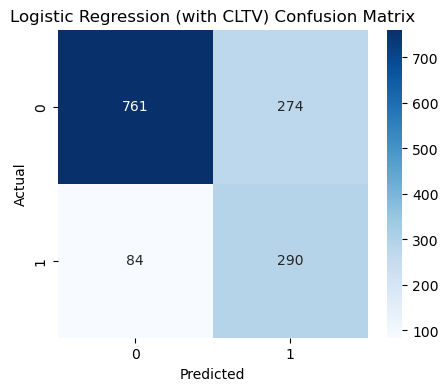

In [80]:
logistic_results = evaluate_model(
    "Logistic Regression (with CLTV)",
    LogisticRegression(random_state=42)
)

Random Forest (with CLTV)
Accuracy : 0.7793
Precision: 0.5827
Recall   : 0.5936
F1-Score : 0.5881
ROC-AUC  : 0.8354

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



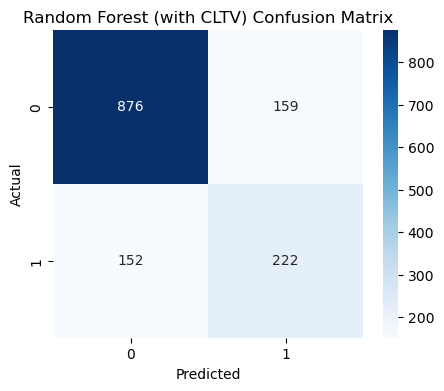

In [81]:
rf_results = evaluate_model(
    "Random Forest (with CLTV)",
    RandomForestClassifier(random_state=42)
)

XGBoost (with CLTV)
Accuracy : 0.7921
Precision: 0.6110
Recall   : 0.5963
F1-Score : 0.6035
ROC-AUC  : 0.8392

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1035
           1       0.61      0.60      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



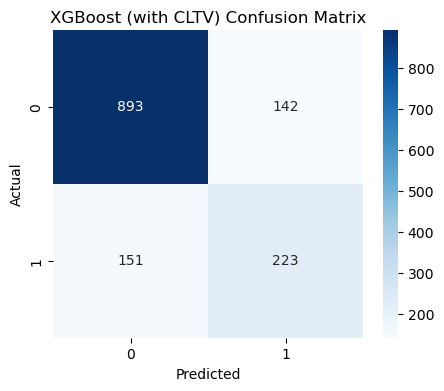

In [82]:
xgb_results = evaluate_model(
    "XGBoost (with CLTV)",
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
)

In [83]:
df = df.drop(columns=["CLTV"])

In [84]:
print(df.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


Logistic Regression (without CLTV)
Accuracy : 0.7459
Precision: 0.5142
Recall   : 0.7754
F1-Score : 0.6183
ROC-AUC  : 0.8467

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



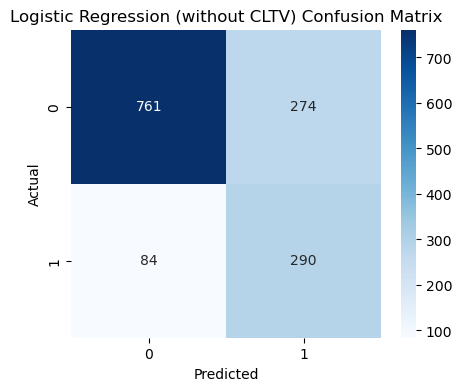

In [85]:
logistic_results_without_CLTV = evaluate_model(
    "Logistic Regression (without CLTV)",
    LogisticRegression(random_state=42)
)

Random Forest (without CLTV)
Accuracy : 0.7793
Precision: 0.5827
Recall   : 0.5936
F1-Score : 0.5881
ROC-AUC  : 0.8354

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



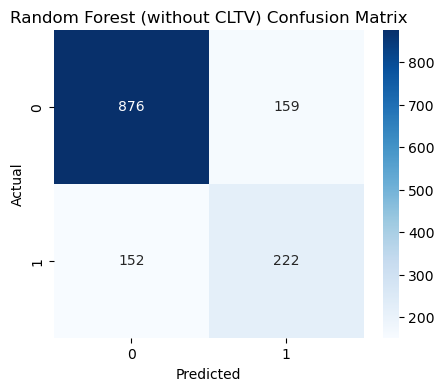

In [86]:
rf_results_without_CLTV = evaluate_model(
    "Random Forest (without CLTV)",
    RandomForestClassifier(random_state=42)
)

XGBoost (without CLTV)
Accuracy : 0.7921
Precision: 0.6110
Recall   : 0.5963
F1-Score : 0.6035
ROC-AUC  : 0.8392

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1035
           1       0.61      0.60      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



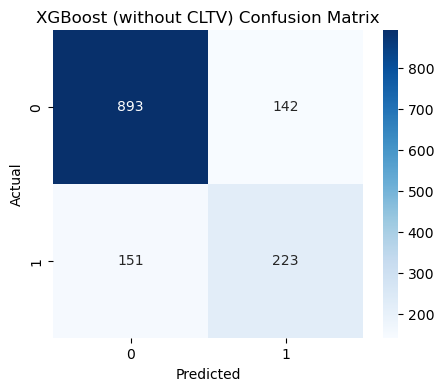

In [87]:
xgb_results_without_CLTV = evaluate_model(
    "XGBoost (without CLTV)",
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
)

In [88]:
results = pd.DataFrame([
    logistic_results,
    logistic_results_without_CLTV,
    rf_results,
    rf_results_without_CLTV,
    xgb_results,    
    xgb_results_without_CLTV
])

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (with CLTV),0.745919,0.514184,0.775401,0.618337,0.846741
1,Logistic Regression (without CLTV),0.745919,0.514184,0.775401,0.618337,0.846741
2,Random Forest (with CLTV),0.779276,0.582677,0.593583,0.588079,0.835377
3,Random Forest (without CLTV),0.779276,0.582677,0.593583,0.588079,0.835377
4,XGBoost (with CLTV),0.792051,0.610959,0.596257,0.603518,0.839152
5,XGBoost (without CLTV),0.792051,0.610959,0.596257,0.603518,0.839152


In [89]:
# ==========================================================
# Feature Selection Experiment: Customer Lifetime Value (CLTV)
# ==========================================================
#
# An experiment was conducted to evaluate whether including
# Customer Lifetime Value (CLTV) improves model performance.
#
# Logistic Regression, Random Forest, and XGBoost were trained
# with and without CLTV.
#
# The evaluation metrics (Accuracy, Precision, Recall,
# F1-Score, and ROC-AUC) remained identical across all models.
#
# Therefore, CLTV was excluded from the final model because it
# did not provide additional predictive value and removing it
# results in a simpler, more interpretable model.
# ==========================================================

In [92]:
# ==========================================================
#Hyperparameter Tuning
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}

In [93]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(random_state=42))
])

In [94]:
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="recall",
    random_state=42,
    n_jobs=-1
)

In [95]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Tenure '
                                                                                'Months',
                                                                                'Monthly '
                                                                                'Charges',
                                                                                'Total '
                                                                                'Charges',
                                                                                'CLTV']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               ['Gender',
                                                                                'Senior '
                                                                                'Citizen',
                                                                                'Partner',
                                                                                'Dependents',
                                                                                'Phone '
                                                                                'Service',
                                                                                'Multiple '
                                                                                'Lines',
                                                                                'Internet '
                                                                                'Service',...
                                                                                'Support',
                                                                                'Streaming '
                                                                                'TV',
                                                                                'Streaming '
                                                                                'Movies',
                                                                                'Contract',
                                                                                'Paperless '
                                                                                'Billing',
                                                                                'Payment '
                                                                                'Method'])])),
                                             ('smote', SMOTE(random_state=42)),
                                             ('classifier',
                                              LogisticRegression(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__C': [0.01, 0.1, 1, 10,
                                                          100],
                                        'classifier__penalty': ['l1', 'l2'],
                                        'classifier__solver': ['liblinear']},
                   random_state=42, scoring='recall')

In [96]:
print(random_search.best_params_)

{'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__C': 100}


In [97]:
print(random_search.best_score_)

0.8093645484949834


In [98]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [101]:
tuned_results = {
    "Model": "Tuned Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

In [102]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7444996451383961
Precision: 0.5123239436619719
Recall   : 0.7780748663101604
F1 Score : 0.6178343949044586
ROC AUC  : 0.8458162184504896


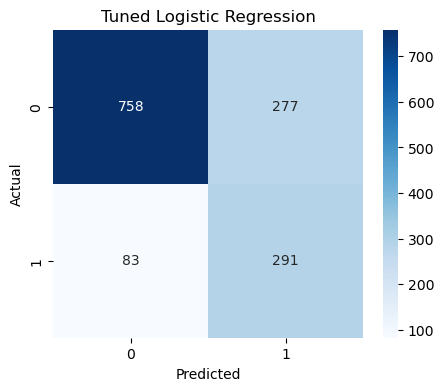

In [103]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [104]:
baseline_results = {
    "Model": "Baseline Logistic Regression",
    "Accuracy": 0.7459,
    "Precision": 0.5142,
    "Recall": 0.7754,
    "F1-Score": 0.6183,
    "ROC-AUC": 0.8467
}

In [105]:
comparison = pd.DataFrame([
    baseline_results,
    tuned_results
])

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Logistic Regression,0.7459,0.514200,0.775400,0.618300,0.846700
1,Tuned Logistic Regression,0.7445,0.512324,0.778075,0.617834,0.845816


In [106]:
## Hyperparameter Tuning Summary

# RandomizedSearchCV was used to optimize the Logistic Regression model using 5-fold cross-validation with Recall as the optimization metric.

# Although the tuned model achieved a slightly higher Recall (0.7781 vs. 0.7754), the improvement was minimal and accompanied by slight decreases in Accuracy, Precision, and ROC-AUC.

# Overall, hyperparameter tuning did not produce a meaningful improvement in predictive performance. Therefore, the baseline Logistic Regression model was selected as the final model due to its comparable performance and simpler configuration.

In [107]:
# Get feature names after preprocessing

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

print(feature_names)

['num__Tenure Months' 'num__Monthly Charges' 'num__Total Charges'
 'num__CLTV' 'cat__Gender_Male' 'cat__Senior Citizen_Yes'
 'cat__Partner_Yes' 'cat__Dependents_Yes' 'cat__Phone Service_Yes'
 'cat__Multiple Lines_No phone service' 'cat__Multiple Lines_Yes'
 'cat__Internet Service_Fiber optic' 'cat__Internet Service_No'
 'cat__Online Security_No internet service' 'cat__Online Security_Yes'
 'cat__Online Backup_No internet service' 'cat__Online Backup_Yes'
 'cat__Device Protection_No internet service' 'cat__Device Protection_Yes'
 'cat__Tech Support_No internet service' 'cat__Tech Support_Yes'
 'cat__Streaming TV_No internet service' 'cat__Streaming TV_Yes'
 'cat__Streaming Movies_No internet service' 'cat__Streaming Movies_Yes'
 'cat__Contract_One year' 'cat__Contract_Two year'
 'cat__Paperless Billing_Yes'
 'cat__Payment Method_Credit card (automatic)'
 'cat__Payment Method_Electronic check' 'cat__Payment Method_Mailed check']


In [108]:
coefficients = best_model.named_steps["classifier"].coef_[0]

In [109]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df.head()

,Feature,Coefficient
0,num__Tenure Months,-1.319404
1,num__Monthly Charges,-1.866929
2,num__Total Charges,0.690480
3,num__CLTV,0.039383
4,cat__Gender_Male,0.062811


In [110]:
importance_df["Absolute Coefficient"] = importance_df["Coefficient"].abs()

importance_df = importance_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

importance_df.head(15)

,Feature,Coefficient,Absolute Coefficient
11,cat__Internet Service_Fiber optic,2.226086,2.226086
7,cat__Dependents_Yes,-1.927779,1.927779
1,num__Monthly Charges,-1.866929,1.866929
26,cat__Contract_Two year,-1.457677,1.457677
0,num__Tenure Months,-1.319404,1.319404
9,cat__Multiple Lines_No phone service,-0.984933,0.984933
24,cat__Streaming Movies_Yes,0.906662,0.906662
25,cat__Contract_One year,-0.884708,0.884708
22,cat__Streaming TV_Yes,0.764594,0.764594
2,num__Total Charges,0.690480,0.690480


In [132]:
importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", ": ")
)

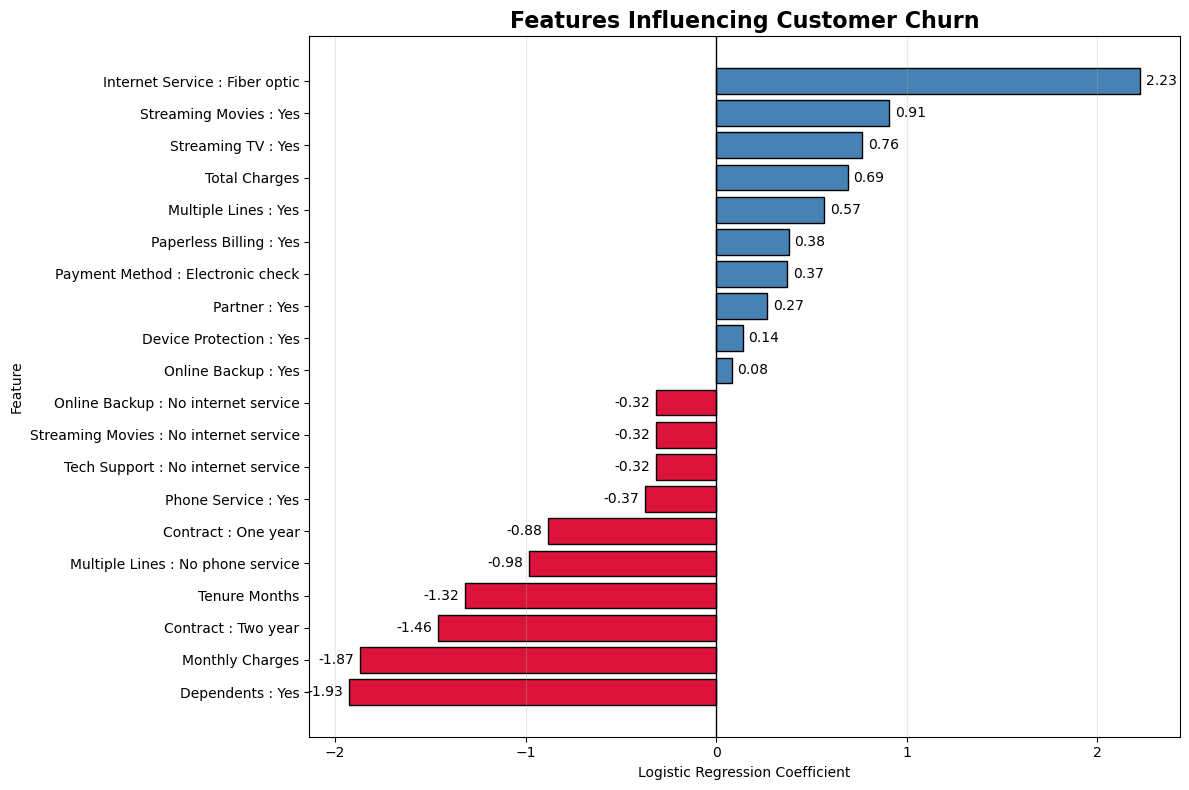

In [133]:
coef_df = importance_df.sort_values("Coefficient")

top_negative = coef_df.head(10)
top_positive = coef_df.tail(10)

plot_df = pd.concat([top_negative, top_positive])

plt.figure(figsize=(12,8))

colors = [
    "crimson" if coef < 0 else "steelblue"
    for coef in plot_df["Coefficient"]
]

bars = plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"],
    color=colors,
    edgecolor="black"
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title(
    "Features Influencing Customer Churn",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.grid(axis="x", alpha=0.3)

# Add coefficient values
for bar in bars:
    width = bar.get_width()

    if width >= 0:
        plt.text(
            width + 0.03,
            bar.get_y() + bar.get_height()/2,
            f"{width:.2f}",
            va="center",
            fontsize=10
        )
    else:
        plt.text(
            width - 0.03,
            bar.get_y() + bar.get_height()/2,
            f"{width:.2f}",
            va="center",
            ha="right",
            fontsize=10
        )

plt.tight_layout()
plt.show()

In [134]:
# ==========================================================
# Feature Importance Interpretation
# ==========================================================
#
# The feature importance analysis is based on the coefficients of the final Logistic Regression model.
#
# Positive coefficients indicate features associated with a higher likelihood of customer churn, while negative coefficients indicate features associated with customer retention. 
# The larger the absolute coefficient, the stronger the feature's influence on the model's predictions.
#
# Key observations:
# - Customers using Fiber Optic Internet Service showed the highest likelihood of churning.
# - Customers with longer tenure, dependents, and long-term contracts were less likely to churn.
# - Features such as Streaming TV, Streaming Movies, and Electronic Check payment method were associated with a higher probability of churn.
#
# Note:
# Logistic Regression coefficients describe statistical relationships rather than causal effects. 
# Since numerical variables were standardized and some features may becorrelated, coefficient values should be interpretedalongside business knowledge.
# ==========================================================

In [135]:
# ==========================================================
# Business Recommendations
# ==========================================================
#
# Based on the model findings, the following business recommendations are proposed:
#
# 1. Encourage customers to switch from month-to-month plans to one- or two-year contracts through loyalty rewards or promotional discounts.
#
# 2. Prioritize retention campaigns for customers using Fiber Optic Internet Service, as this group demonstrated the highest churn risk.
#
# 3. Strengthen customer engagement during the early stages of the customer lifecycle, since customers with longer tenure were less likely to churn.
#
# 4. Monitor customers using Electronic Check and Paperless Billing, as these segments may benefit from targeted retention initiatives.
#
# 5. Continue developing products and services that appeal to family-oriented customers, as customers with dependents showed stronger customer retention.
# ==========================================================

In [136]:
# ==========================================================
# Project Conclusion
# ==========================================================
#
# Three machine learning models were developed to predict customer churn: Logistic Regression, Random Forest, and XGBoost.
#
# Logistic Regression achieved the best overall performance, producing the highest Recall and ROC-AUC among the models evaluated. Since customer churn prediction aims to identify
# as many customers at risk of leaving as possible, Recall was selected as the primary evaluation metric.
#
# A feature selection experiment showed that removing Customer Lifetime Value (CLTV) did not affect model performance,
# indicating that CLTV did not provide additional predictive value for this dataset.
#
# Hyperparameter tuning using RandomizedSearchCV resulted in only marginal improvements, suggesting that the baseline
# Logistic Regression model was already well suited for the problem.
#
# Overall, this project demonstrates a complete end-to-end machine learning workflow, including data cleaning, exploratory data analysis, preprocessing using
# ColumnTransformer and Pipeline, handling class imbalance with SMOTE, model development, hyperparameter tuning, feature interpretation, and business recommendations.
# ==========================================================

In [141]:
# ==========================================================
# Generate Predictions for Power BI Dashboard
# ==========================================================
#
# The final Logistic Regression model is used to predict customer churn for the entire dataset. The predicted churn
# labels and churn probabilities are exported for use in a Power BI dashboard.
#
# Churn Probability represents the likelihood that a customer will churn, with values closer to 1 indicating higher risk.
# ==========================================================

In [139]:
# Predict churn
predictions = best_model.predict(X)

# Predict churn probability
probabilities = best_model.predict_proba(X)[:, 1]

In [140]:
results = df.copy()

results["Predicted Churn"] = predictions
results["Churn Probability"] = probabilities

In [142]:
results["Predicted Churn"] = results["Predicted Churn"].map({
    0: "No",
    1: "Yes"
})

In [ ]:
results.to_excel(
    "Customer_Churn_Predictions.xlsx",
    index=False
)